In [1]:
import matplotlib.pyplot as plt
import numpy as np
import string 
import h5py

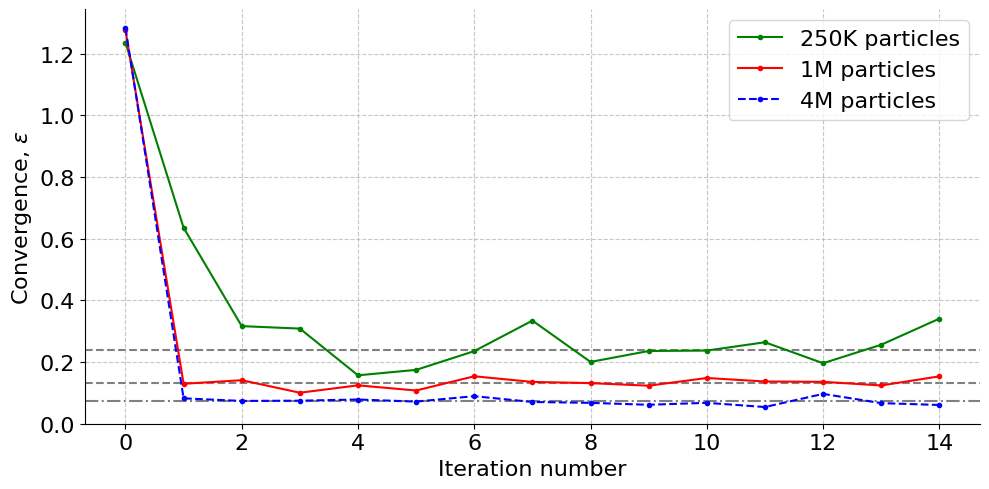

In [3]:
# iteration plot 
# paths 

two_fifty_k = '/home/jacobvandelindt/aorsa_cql_mcgo_toolkit/shots/147634/epsilon_250K.txt'
one_million = '/home/jacobvandelindt/aorsa_cql_mcgo_toolkit/shots/147634/epsilon_1M.txt'
# four_million = '/home/jacobvandelindt/aorsa_cql_mcgo_toolkit/shots/147634/epsilon_4M.txt'
four_million = '/home/jacobvandelindt/aorsa_cql_mcgo_toolkit/shots/147634/epsilon_4M.txt'
# load up data 

two_fifty_k_data = np.loadtxt(two_fifty_k, delimiter=',')
one_million_data = np.loadtxt(one_million, delimiter=',')
four_million_data = np.loadtxt(four_million, delimiter=',')

avg_250k = np.average(two_fifty_k_data[4:])
avg_one = np.average(one_million_data[1:])
avg_four = np.average(four_million_data[1:15])

font_size = 16
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(two_fifty_k_data, marker='.', color='green', label='250K particles')
ax.plot(one_million_data, marker='.', color='red', label='1M particles')
ax.plot(four_million_data[:15], marker='.', color='blue', label='4M particles', linestyle='--')
ax.set_xlabel('Iteration number', fontsize=font_size)
ax.set_ylabel(r'Convergence, $\epsilon$', fontsize=font_size)
ax.axhline(y=avg_250k, zorder=0, color='grey', linestyle='--')
ax.axhline(y=avg_one, zorder=0, color='grey', linestyle='--')
ax.axhline(y=avg_four, zorder=0, color='grey', linestyle='-.')

# usual plot specs
ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=font_size)
ax.legend(fontsize=font_size)
ax.set_ylim(0, None)
plt.tight_layout()

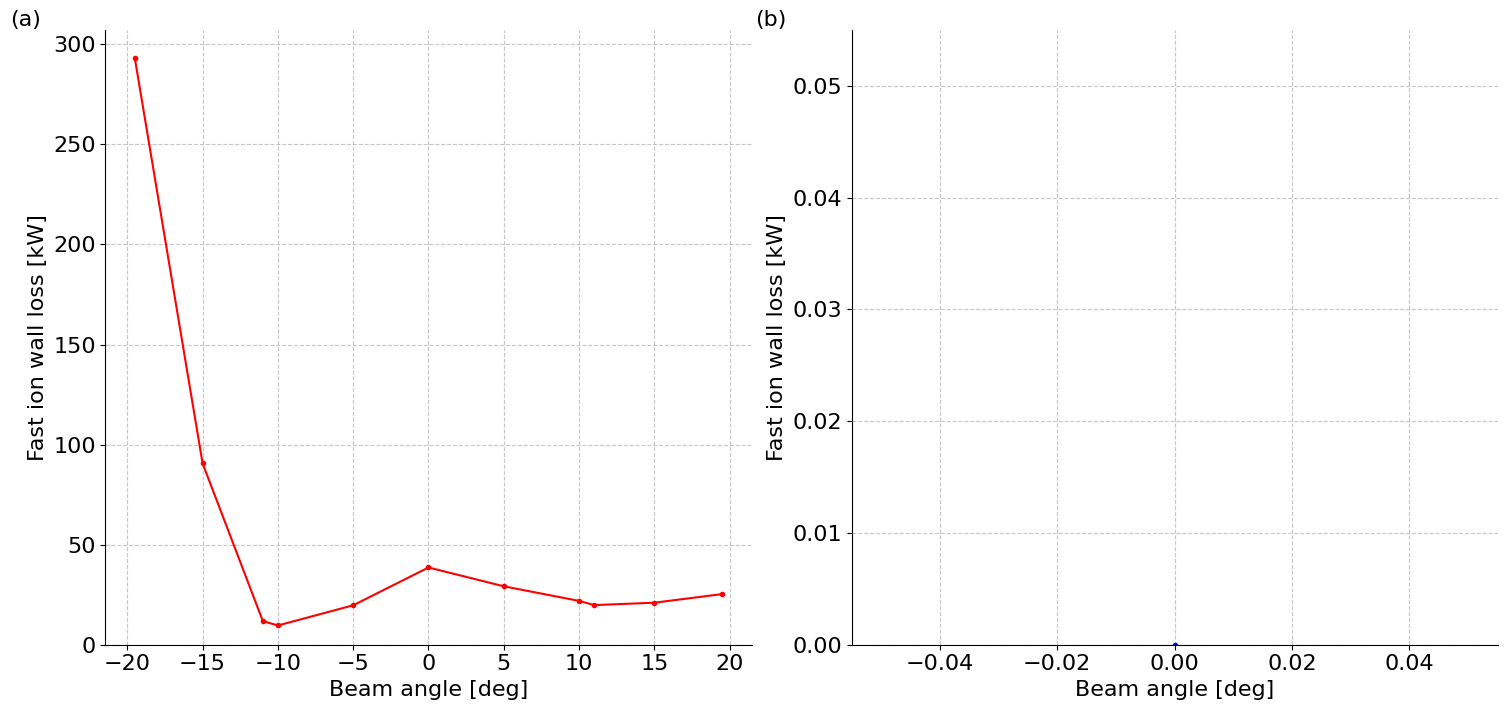

In [18]:
high_qmin_angles = [-19.5, -15, -11,   -10,  -5,    0,    5,   10,   11,   15, 19.5]
high_qmin_losseskw = [293, 90.6, 11.8, 9.62, 19.7, 38.6, 29.2, 21.9, 19.8, 21, 25.3]

# beam angle losses plots 
font_size = 16
fig, ax = plt.subplots(1,2,figsize=(15,7))

ax[0].plot(high_qmin_angles, high_qmin_losseskw, color='red', marker='.')
ax[0].set_xlabel('Beam angle [deg]', fontsize=font_size)
ax[0].set_ylabel(r'Fast ion wall loss [kW]', fontsize=font_size)

# usual plot specs
ax[0].grid(True, linestyle='--', alpha=0.7)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].tick_params(axis='both', labelsize=font_size)
ax[0].set_ylim(0, None)


# super H mode 
ax[1].plot(0,0, color='blue', marker='.')
ax[1].set_xlabel('Beam angle [deg]', fontsize=font_size)
ax[1].set_ylabel(r'Fast ion wall loss [kW]', fontsize=font_size)

# usual plot specs
ax[1].grid(True, linestyle='--', alpha=0.7)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].tick_params(axis='both', labelsize=font_size)
ax[1].set_ylim(0, None)
plt.tight_layout()


axes_flat = ax.flatten()
for i, ax in enumerate(axes_flat):
    # Plot some dummy data
    
    # Generate the letter (a, b, c, d...)
    letter = string.ascii_lowercase[i]
    
    # 3. Add the text
    # x=-0.1, y=1.05 places it slightly outside the top-left corner.
    # transform=ax.transAxes binds the coordinates to the plot frame, not the data.
    ax.text(-0.1, 1.0, f"({letter})", 
            transform=ax.transAxes, 
            fontsize=font_size, 
            va='bottom', 
            ha='right')


In [5]:
def load_entire_h5_to_dict(filename):
    """
    Reads an entire HDF5 parameter scan file and returns it as a nested dictionary,
    safely handling any nested Groups or Datasets.
    """
    
    # We define a helper function to recursively unpack the file
    def _recurse(h5_obj):
        temp_dict = {}
        for key in h5_obj.keys():
            item = h5_obj[key]
            
            # If it's a dataset, unpack the data
            if isinstance(item, h5py.Dataset):
                if item.shape == ():
                    temp_dict[key] = item[()]  # Unpack scalar
                else:
                    temp_dict[key] = item[:].tolist()  # Unpack array
                    
            # If it's a group, dive into it recursively
            elif isinstance(item, h5py.Group):
                temp_dict[key] = _recurse(item)
                
        return temp_dict

    # Open the file and start the recursion from the root
    with h5py.File(filename, 'r') as f:
        master_dict = _recurse(f)
        
    return master_dict

In [10]:
# shot 14... main profiles figure 

data_file_path = '/home/jacobvandelindt/aorsa_cql_mcgo_toolkit/shots/147634/paper2_scans/scan_data.h5'

data_dict = load_entire_h5_to_dict(filename=data_file_path)
print(data_dict.keys())
print(data_dict['beamtot_10_RFtot_1900'].keys())

dict_keys(['beamtot_10_RFtot_1900', 'beamtot_10_RFtot_300'])
dict_keys(['B0 [T]', 'DD Neutron Rate [n_per_s*cm^3]', 'NBI Temp [keV]', 'NBI beta', 'NBI density [m^-3]', 'NBI rhoL_per_a', 'NBI v_per_vA', 'RF Power [MW_per_m^3]', 'RF Temp [keV]', 'RF beta', 'RF density [m^-3]', 'RF rhoL_per_a', 'RF v_per_vA', 'aorsa powers to ions [W]', 'ni0 [m^-3]', 'rho_mcgo_lfs', 'rho_sqrt_psi_mfile', 'vA [m_per_s]'])


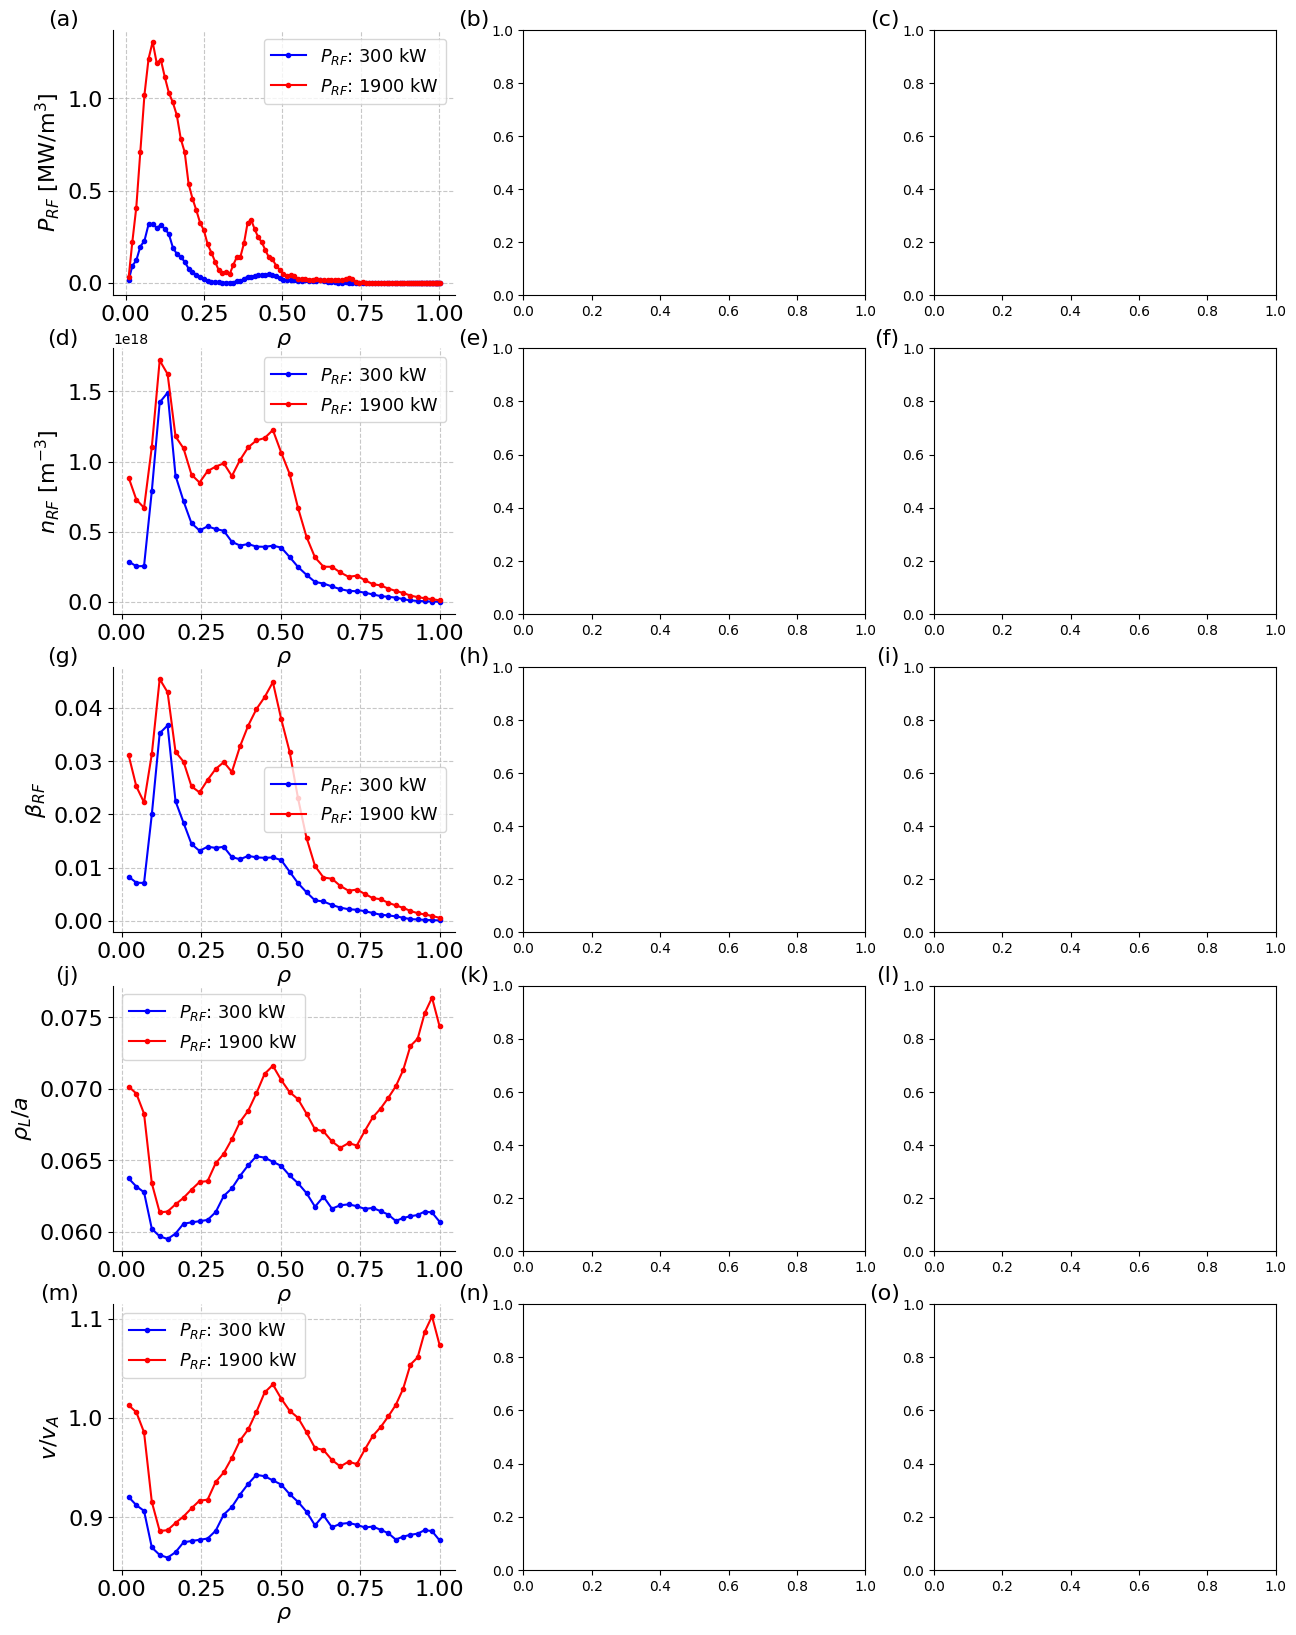

In [37]:
# big figure 1. its 3 collumns by 3 rows.
# columns: beam powers 
# rows: RF power, nRF, beta, rhoL/a, v/vA
nbi_powers_prefix = [10]
rf_powers_prefix = [300, 1900]
rf_colors_list = ['blue', 'red']

font_size = 16
fig, ax = plt.subplots(5,3,figsize=(15,20))

for nbi_i, nbi_prefix in enumerate(nbi_powers_prefix):
    rfpower_ax = ax[0, nbi_i]
    rfn_ax = ax[1, nbi_i]
    beta_ax = ax[2, nbi_i]
    rhol_ax = ax[3, nbi_i]
    vva_ax = ax[4, nbi_i]

    # rf powers plot 
    rfpower_ax.set_xlabel(r'$\rho$', fontsize=font_size)
    rfpower_ax.set_ylabel(r'$P_{RF}$ [MW/m$^3$]', fontsize=font_size)
    rfpower_ax.grid(True, linestyle='--', alpha=0.7)
    rfpower_ax.spines['top'].set_visible(False)
    rfpower_ax.spines['right'].set_visible(False)
    rfpower_ax.tick_params(axis='both', labelsize=font_size)

    # now, loop over the RF powers and plot 
    for rf_i, rf_prefix in enumerate(rf_powers_prefix):
        color=rf_colors_list[rf_i]
        case_key = f'beamtot_{nbi_prefix}_RFtot_{rf_prefix}'
        rho = data_dict[case_key]['rho_sqrt_psi_mfile']
        #NBI_beta = data_dict[case_key]['NBI beta']
        RF_v_over_va = data_dict[case_key]['RF Power [MW_per_m^3]']

        #beta_ax.plot(rho, NBI_beta, marker='.', linestyle='--', label=r'$\beta_{NBI}$, $P_{RF}$: ' + f'{rf_prefix} kW', color=color)
        rfpower_ax.plot(rho, RF_v_over_va, marker='.',  label=r'$P_{RF}$: ' + f'{rf_prefix} kW', color=color)
    rfpower_ax.legend(fontsize=font_size*.8)

    # rf densities 
    rfn_ax.set_xlabel(r'$\rho$', fontsize=font_size)
    rfn_ax.set_ylabel(r'$n_{RF}$ [m$^{-3}$]', fontsize=font_size)
    rfn_ax.grid(True, linestyle='--', alpha=0.7)
    rfn_ax.spines['top'].set_visible(False)
    rfn_ax.spines['right'].set_visible(False)
    rfn_ax.tick_params(axis='both', labelsize=font_size)

    # now, loop over the RF powers and plot 
    for rf_i, rf_prefix in enumerate(rf_powers_prefix):
        color=rf_colors_list[rf_i]
        case_key = f'beamtot_{nbi_prefix}_RFtot_{rf_prefix}'
        rho = data_dict[case_key]['rho_mcgo_lfs']
        #NBI_beta = data_dict[case_key]['NBI beta']
        RF_v_over_va = data_dict[case_key]['RF density [m^-3]']

        #beta_ax.plot(rho, NBI_beta, marker='.', linestyle='--', label=r'$\beta_{NBI}$, $P_{RF}$: ' + f'{rf_prefix} kW', color=color)
        rfn_ax.plot(rho, RF_v_over_va, marker='.',  label=r'$P_{RF}$: ' + f'{rf_prefix} kW', color=color)
    rfn_ax.legend(fontsize=font_size*.8)

    # beta figure 
    beta_ax.set_xlabel(r'$\rho$', fontsize=font_size)
    beta_ax.set_ylabel(r'$\beta_{RF}$', fontsize=font_size)
    beta_ax.grid(True, linestyle='--', alpha=0.7)
    beta_ax.spines['top'].set_visible(False)
    beta_ax.spines['right'].set_visible(False)
    beta_ax.tick_params(axis='both', labelsize=font_size)

    # now, loop over the RF powers and plot 
    for rf_i, rf_prefix in enumerate(rf_powers_prefix):
        color=rf_colors_list[rf_i]
        case_key = f'beamtot_{nbi_prefix}_RFtot_{rf_prefix}'
        rho = data_dict[case_key]['rho_mcgo_lfs']
        #NBI_beta = data_dict[case_key]['NBI beta']
        RF_beta = data_dict[case_key]['RF beta']

        #beta_ax.plot(rho, NBI_beta, marker='.', linestyle='--', label=r'$\beta_{NBI}$, $P_{RF}$: ' + f'{rf_prefix} kW', color=color)
        beta_ax.plot(rho, RF_beta, marker='.',  label=r'$P_{RF}$: ' + f'{rf_prefix} kW', color=color)
    beta_ax.legend(fontsize=font_size*.8)

    # rho_over_a figure 
    rhol_ax.set_xlabel(r'$\rho$', fontsize=font_size)
    rhol_ax.set_ylabel(r'$\rho_{L}/a$', fontsize=font_size)
    rhol_ax.grid(True, linestyle='--', alpha=0.7)
    rhol_ax.spines['top'].set_visible(False)
    rhol_ax.spines['right'].set_visible(False)
    rhol_ax.tick_params(axis='both', labelsize=font_size)

    # now, loop over the RF powers and plot 
    for rf_i, rf_prefix in enumerate(rf_powers_prefix):
        color=rf_colors_list[rf_i]
        case_key = f'beamtot_{nbi_prefix}_RFtot_{rf_prefix}'
        rho = data_dict[case_key]['rho_mcgo_lfs']
        #NBI_beta = data_dict[case_key]['NBI beta']
        RF_rhol_over_a = data_dict[case_key]['RF rhoL_per_a']

        #beta_ax.plot(rho, NBI_beta, marker='.', linestyle='--', label=r'$\beta_{NBI}$, $P_{RF}$: ' + f'{rf_prefix} kW', color=color)
        rhol_ax.plot(rho, RF_rhol_over_a, marker='.',  label=r'$P_{RF}$: ' + f'{rf_prefix} kW', color=color)
    rhol_ax.legend(fontsize=font_size*.8)

    # v/vA plot 
    vva_ax.set_xlabel(r'$\rho$', fontsize=font_size)
    vva_ax.set_ylabel(r'$v/v_A$', fontsize=font_size)
    vva_ax.grid(True, linestyle='--', alpha=0.7)
    vva_ax.spines['top'].set_visible(False)
    vva_ax.spines['right'].set_visible(False)
    vva_ax.tick_params(axis='both', labelsize=font_size)

    # now, loop over the RF powers and plot 
    for rf_i, rf_prefix in enumerate(rf_powers_prefix):
        color=rf_colors_list[rf_i]
        case_key = f'beamtot_{nbi_prefix}_RFtot_{rf_prefix}'
        rho = data_dict[case_key]['rho_mcgo_lfs']
        #NBI_beta = data_dict[case_key]['NBI beta']
        RF_v_over_va = data_dict[case_key]['RF v_per_vA']

        #beta_ax.plot(rho, NBI_beta, marker='.', linestyle='--', label=r'$\beta_{NBI}$, $P_{RF}$: ' + f'{rf_prefix} kW', color=color)
        vva_ax.plot(rho, RF_v_over_va, marker='.',  label=r'$P_{RF}$: ' + f'{rf_prefix} kW', color=color)
    vva_ax.legend(fontsize=font_size*.8)

axes_flat = ax.flatten()
for i, ax in enumerate(axes_flat):
    # Plot some dummy data
    
    # Generate the letter (a, b, c, d...)
    letter = string.ascii_lowercase[i]
    
    # 3. Add the text
    # x=-0.1, y=1.05 places it slightly outside the top-left corner.
    # transform=ax.transAxes binds the coordinates to the plot frame, not the data.
    ax.text(-0.1, 1.0, f"({letter})", 
            transform=ax.transAxes, 
            fontsize=font_size, 
            va='bottom', 
            ha='right')



In [ ]:
# big figure 2. its 3 collumns by 2 rows.
# columns: beam powers 
# rows: RF power to ions, nfast. 